## Abaltions for lambda threshold.

In [23]:
def default_params(): 
    return {
        'input_path': '/workspaces/CodeSmells/data/extension/causality/dataset',
        'intervention' : 'T1', # 'T1' for generation_type, 'T2' for model_size, 'T3' for model_architecture, 'T4' for prompt
        'cache_dir': '/workspaces/CodeSmells/datax/hugging_face_cache',
        'top-k':10
    }
params = default_params()

### Imports

In [2]:
import pandas as pd
import numpy as np
from dowhy import CausalModel
import dowhy.datasets
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import zscore
import json
import os
import scipy.stats as stats
import re

In [3]:
import matplotlib.pyplot as plt

### Dataset loading

In [4]:
causal_hypothesis_df = pd.read_json(f"{params['input_path']}/{params['intervention']}.json")

In [17]:
causal_hypothesis_df['code_smell_actual_prob_median']

0         0.985243
1         0.676999
2         0.989127
3         0.085771
4         0.604125
            ...   
145622    0.541213
145623    0.640082
145624    0.827682
145625    0.444584
145626    0.430107
Name: code_smell_actual_prob_median, Length: 145627, dtype: float64

In [18]:
causal_hypothesis_df.columns

Index(['category', 'actual_prob', 'nloc', 'code_smell_max_prob_mean',
       'n_ast_nodes', 'id', 'code_smell_max_logits', 'complexity', 's_code',
       'ast_errors', 'loss', 'file_name', 'code', 'n_whitespaces',
       'token_counts', 'code_smell_actual_prob_median', 's_line', 'max_prob',
       'input_lenght', 'language', 'code_smell_min_logits', 'vocab_size',
       'code_smell_actual_prob_mean', 'n_identifiers', 'ast_levels',
       'code_smell_psc_relative', 'commit_id', 's_end_column', 'repo',
       'input_ids', 'code_smell_max_prob_median', 'code_smell_pos', 'n_words',
       'code_smell_psc_entropy', 'url', 'code_smell_min_prob_mean',
       'treatment', 'code_smell_min_prob_median', 'path', 's_msg_id',
       's_column', 'code_smell_actual_logits', 'n_ast_errors', 'fun_name',
       'min_prob', 's_end_line', 'commit_message', 'NOUN', 'PROPN', 'VERB',
       'ADJ', 'ADV', 'NUM', 'INTJ'],
      dtype='object')

/tmp/ipykernel_49151/2769762696.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("crest", num_smells)
/tmp/ipykernel_49151/2769762696.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  smells_distribution_plot = sns.boxplot(


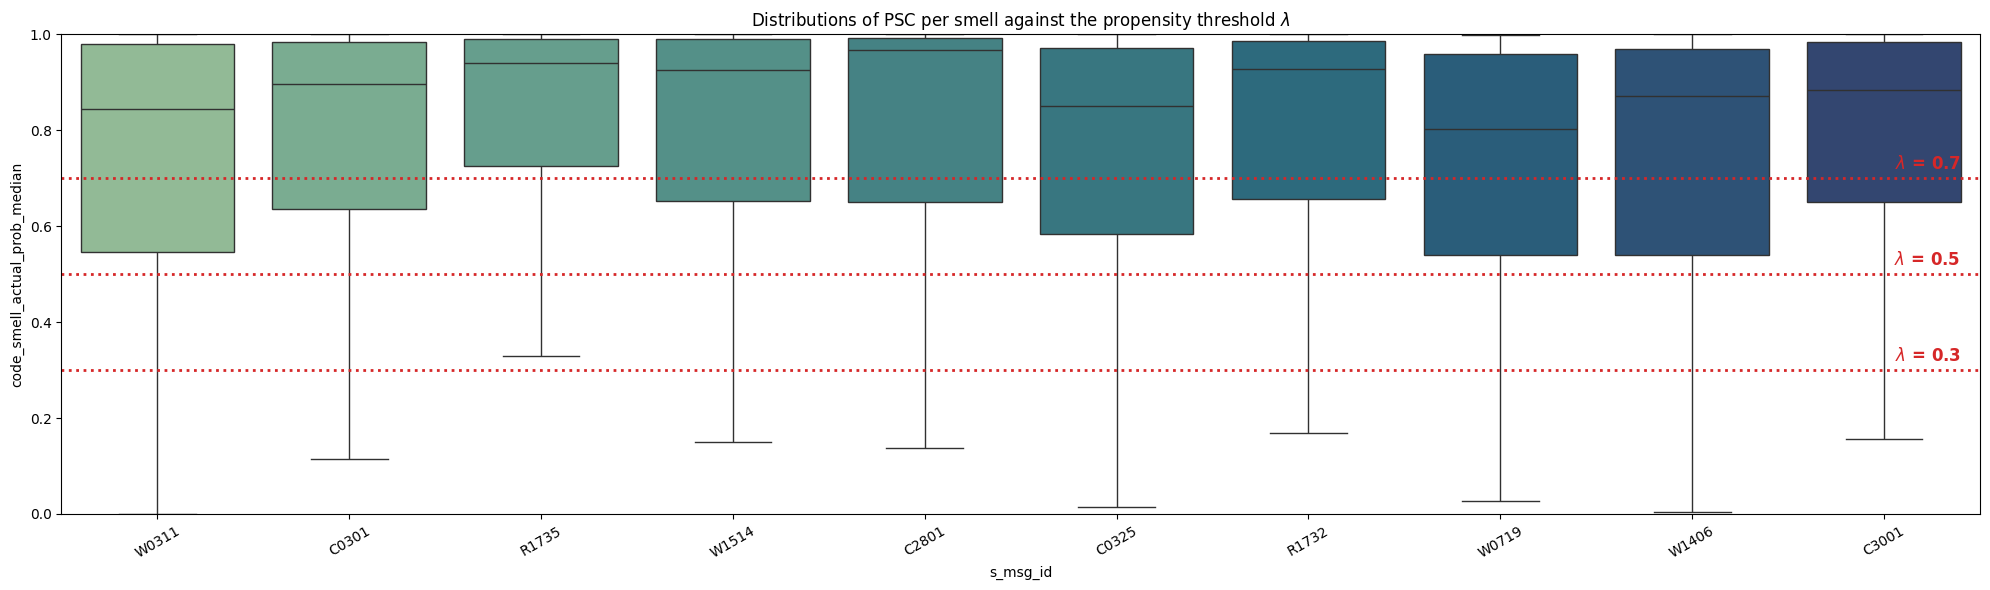

In [ ]:
# ...existing code...

import matplotlib.cm as cm

causal_hypothesis_df = causal_hypothesis_df[causal_hypothesis_df['treatment'] == 'curated']
mean_probs = causal_hypothesis_df.groupby("s_msg_id")["code_smell_actual_prob_median"].mean()
top_smells = mean_probs[(mean_probs > 0.7) & (mean_probs < 0.8)].nlargest(params['top-k']).index
filtered_df = causal_hypothesis_df[causal_hypothesis_df["s_msg_id"].isin(top_smells)]


# Get number of unique code smells for color mapping
num_smells = filtered_df["s_msg_id"].nunique()
colors = cm.get_cmap("crest", num_smells)

plt.figure(figsize=(20, 6))
smells_distribution_plot = sns.boxplot(
    data=filtered_df,
    y="code_smell_actual_prob_median", 
    x="s_msg_id", 
    fliersize=0,
    color=None,
    palette="crest"
)
smells_distribution_plot.set(
    xlabel="",
    ylabel="",
    title=f"Distributions of PSC per smell against the propensity threshold $\\lambda$"
)
smells_distribution_plot.set_ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()

# Add horizontal dotted red lines at 0.3, 0.5, and 0.7 with labels
for y in [0.3, 0.5, 0.7]:
    plt.axhline(y=y, color="#d62728", linestyle=":", linewidth=2)
    plt.text(
        0.99, y + 0.01, f"$\\lambda$ = {y}", color="#d62728", fontsize=12, fontweight="bold",
        ha="right", va="bottom", transform=smells_distribution_plot.get_yaxis_transform()
    )

plt.show()
# ...existing code...